# 1. Setup

In [27]:
# Import necessary libraries
import numpy as np
from tqdm import tqdm

import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from pytagi import exponential_scheduler
from pytagi.nn import LSTM, Linear, OutputUpdater, Sequential

from examples.data_loader import TimeSeriesDataloader
from examples.time_series_forecasting import PredictionViz

# 2. Prepare data

In [28]:
# Dataset
output_col = [0] # column to predict
num_features = 1 # number of features
input_seq_len = 5 # input sequence length
output_seq_len = 1 # output sequence length
seq_stride = 1 # stride

train_dtl = TimeSeriesDataloader(
    x_file="/Users/davidwardan/PycharmProjects/cuTAGI_DW/data/toy_time_series/x_train_sin_data.csv",
    date_time_file="/Users/davidwardan/PycharmProjects/cuTAGI_DW/data/toy_time_series/train_sin_datetime.csv",
    output_col=output_col,
    input_seq_len=input_seq_len,
    output_seq_len=output_seq_len,
    num_features=num_features,
    stride=seq_stride,
    )
test_dtl = TimeSeriesDataloader(
    x_file="/Users/davidwardan/PycharmProjects/cuTAGI_DW/data/toy_time_series/x_test_sin_data.csv",
    date_time_file="/Users/davidwardan/PycharmProjects/cuTAGI_DW/data/toy_time_series/test_sin_datetime.csv",
    output_col=output_col,
    input_seq_len=input_seq_len,
    output_seq_len=output_seq_len,
    num_features=num_features,
    stride=seq_stride,
    x_mean=train_dtl.x_mean,
    x_std=train_dtl.x_std,
    )

# 3. Visualizer Initialization

### The `PredictionViz` class is used to visualize the prediction results. The class has the following parameters:

##### `task_name`: Name of the task such as autoencoder
##### `data_name`: Name of dataset such as Boston housing or toy example
##### `figsize`: Size of figure
##### `fontsize`: Font size for letter in the figure
##### `lw`: Linewidth
##### `ms`: Marker size
##### `ndiv_x`: Number of divisions for x-direction
##### `ndiv_y`: Number of divisions for y-direction



In [29]:
viz = PredictionViz(task_name="forecasting", data_name="sin_signal")

# 4. Build Model Architecture

In [30]:
# Network
net = Sequential(
    LSTM(1, 5, input_seq_len),
    LSTM(5, 5, input_seq_len),
    Linear(5 * input_seq_len, 1),
)
# net.to_device("cuda")
# net.set_threads(8)
out_updater = OutputUpdater(net.device)

# 5. Training

In [31]:
# Training parameters
num_epochs = 20 # number of epochs
batch_size = 10 # batch size
sigma_v = 2.0 # observation's variance

# Training loop
mses = []
pbar = tqdm(range(num_epochs), desc="Training Progress")
for epoch in pbar:
    batch_iter = train_dtl.create_data_loader(batch_size)

    # Decaying observation's variance
    sigma_v = exponential_scheduler(
        curr_v=sigma_v, min_v=0.3, decaying_factor=0.99, curr_iter=epoch
    )
    var_y = np.full((batch_size * len(output_col),), sigma_v**2, dtype=np.float32)

    for x, y in batch_iter:
        # Feed forward
        m_pred, _ = net(x)

        # Update output layer
        out_updater.update(
            output_states=net.output_z_buffer,
            mu_obs=y,
            var_obs=var_y,
            delta_states=net.input_delta_z_buffer,
        )

        # Feed backward
        net.backward()
        net.step()

        # Training metric
        pred = normalizer.unstandardize(
            m_pred, train_dtl.x_mean[output_col], train_dtl.x_std[output_col]
        )
        obs = normalizer.unstandardize(
            y, train_dtl.x_mean[output_col], train_dtl.x_std[output_col]
        )
        mse = metric.mse(pred, obs)
        mses.append(mse)

    # Progress bar
    pbar.set_description(
        f"Epoch {epoch + 1}/{num_epochs}| mse: {sum(mses)/len(mses):>7.2f}",
        refresh=True,
    )

Epoch 20/20| mse:    0.88: 100%|██████████| 20/20 [00:02<00:00,  7.29it/s]


# 6. Evaluate and Visualize Results

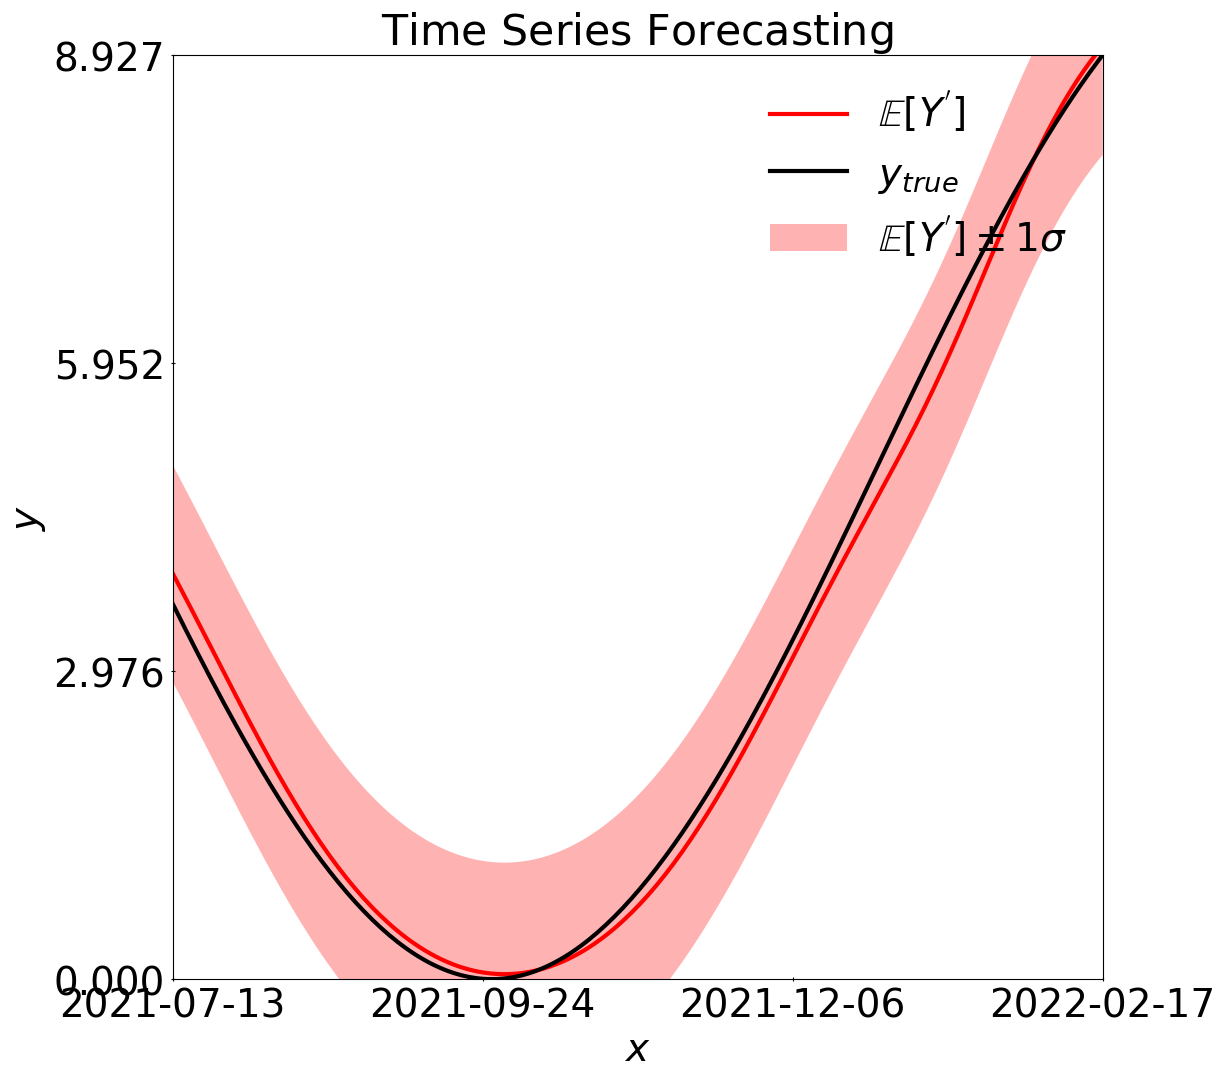

#############
MSE           :  0.04
Log-likelihood: -0.99


In [32]:
# Testing
test_batch_iter = test_dtl.create_data_loader(batch_size, shuffle=False)
mu_preds = []
var_preds = []
y_test = []
x_test = []

for x, y in test_batch_iter:
    # Predicion
    m_pred, v_pred = net(x)

    mu_preds.extend(m_pred)
    var_preds.extend(v_pred + sigma_v**2)
    x_test.extend(x)
    y_test.extend(y)

mu_preds = np.array(mu_preds)
std_preds = np.array(var_preds) ** 0.5
y_test = np.array(y_test)
x_test = np.array(x_test)

mu_preds = normalizer.unstandardize(
    mu_preds, train_dtl.x_mean[output_col], train_dtl.x_std[output_col]
)
std_preds = normalizer.unstandardize_std(std_preds, train_dtl.x_std[output_col])

y_test = normalizer.unstandardize(
    y_test, train_dtl.x_mean[output_col], train_dtl.x_std[output_col]
)

# Compute log-likelihood
mse = metric.mse(mu_preds, y_test)
log_lik = metric.log_likelihood(
    prediction=mu_preds, observation=y_test, std=std_preds
)

# Visualization
viz.plot_predictions(
    x_test=test_dtl.dataset["date_time"][: len(y_test)],
    y_test=y_test,
    y_pred=mu_preds,
    sy_pred=std_preds,
    std_factor=1,
    label="time_series_forecasting",
    title=r"$\text{Time Series Forecasting}$",
    time_series=True,
)

print("#############")
print(f"MSE           : {mse: 0.2f}")
print(f"Log-likelihood: {log_lik: 0.2f}")